In [1]:
import os
os.environ["CCCL_IGNORE_DEPRECATED_CPP_DIALECT"] = "1"
os.environ["MONAI_USE_META_TENSOR"] = "0"

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!python -c "import monai" || pip install -q "monai-weekly[nibabel, tqdm]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 36.3 MB/s eta 0:00:00


In [3]:
import json
import time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import nibabel as nib
import nibabel.processing
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion as scipy_binary_erosion

from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.utils.enums import MetricReduction
import monai.metrics.utils as monai_utils
import monai.metrics.hausdorff_distance as hd_module

from monai.transforms import (
    Activations, AsDiscrete, Compose, LoadImaged, EnsureChannelFirstd,
    MapLabelValued, ConvertToMultiChannelBasedOnBratsClassesd,
    ScaleIntensityRangePercentilesd, CastToTyped, NormalizeIntensityd, MapTransform
)
from monai.data import Dataset, DataLoader, decollate_batch
from monai.networks.blocks import Convolution, ResidualUnit
from monai.networks.layers import Act, Norm

In [4]:
# --- MONKEY PATCH FOR FASTER HAUSDORFF DISTANCE ---
def _patched_get_mask_edges(seg_pred, seg_gt, label_idx=1, crop=True, spacing=None, always_return_as_numpy=False):
    if isinstance(seg_pred, torch.Tensor): seg_pred = seg_pred.cpu().numpy()
    if isinstance(seg_gt, torch.Tensor): seg_gt = seg_gt.cpu().numpy()
    seg_pred, seg_gt = seg_pred.astype(bool), seg_gt.astype(bool)
    edges_pred = seg_pred ^ scipy_binary_erosion(seg_pred)
    edges_gt   = seg_gt   ^ scipy_binary_erosion(seg_gt)
    return torch.tensor(edges_pred), torch.tensor(edges_gt)

monai_utils.get_mask_edges = _patched_get_mask_edges
hd_module.get_mask_edges   = _patched_get_mask_edges
print("cucim monkey patch applied successfully!")

cucim monkey patch applied successfully!


In [5]:
def get_val_loader(data_dir, json_list, fold=None):
    # 1. Read JSON
    with open(json_list) as f:
        json_data = json.load(f)["training"]

    # 2. Parse Paths
    for d in json_data:
        for k in d:
            if isinstance(d[k], list):
                d[k] = [os.path.join(data_dir, iv) for iv in d[k]]
            elif isinstance(d[k], str):
                d[k] = os.path.join(data_dir, d[k]) if len(d[k]) > 0 else d[k]

    # 3. Filter for Validation Fold
    if fold is None:
        val_files = json_data  # load all folds
        print(f"Validation files (all folds): {len(val_files)}")
    else:
        val_files = [d for d in json_data if "fold" in d and d["fold"] == fold]
        print(f"Validation files (fold {fold}): {len(val_files)}")

    # 4. Transforms
    val_transforms = Compose([
        LoadImaged(keys=["image", "label",
                        #  "geodesic_avg"
        ]),
        EnsureChannelFirstd(keys=["image",
                                  # "geodesic_avg"
                                  ]),
        MapLabelValued(keys=["label"], orig_labels=[3], target_labels=[4]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
        ScaleIntensityRangePercentilesd(
            keys="image", lower=0.5, upper=99.5,
            b_min=0.0, b_max=1.0, clip=True, channel_wise=True
        ),
        CastToTyped(keys=["image", "label",
                          # "geodesic_avg"
                          ], dtype=torch.float32),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        # ShiftGeodesicMinusOned(keys=["geodesic_avg"]),
    ])

    # 5. Dataset & Loader
    val_ds = Dataset(data=val_files, transform=val_transforms)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=4)

    return val_loader



# --- GLOBAL VARIABLES ---
# Change this per dataset
fold = 1
roi = (128, 128, 128)
sw_batch_size = 4
infer_overlap = 0.5
SAVE_PREDICTIONS = True # Toggle for NIfTI saving
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset_name = "brats23_glioma"   # e.g. "brats23_glioma", "brats24_ped", "brats24_met"

data_dir  = f"/content/drive/MyDrive/brain_tumor_segmentation/Datasets/{dataset_name}"
json_list = "/content/drive/MyDrive/brain_tumor_segmentation/brats2023_5fold.json"

val_loader = get_val_loader(data_dir, json_list, fold=1)

Validation files (fold 1): 250


In [6]:
# --- MODEL ARCHITECTURE ---
class ConfigurableDualHeadUNet(nn.Module):
    def __init__(self, spatial_dims=3, in_channels=4, out_channels=3,
                 channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2),
                 num_res_units=2, act=Act.PRELU, norm=Norm.INSTANCE, dropout=0.0):
        super().__init__()
        self.spatial_dims, self.num_res_units, self.act, self.norm, self.dropout = spatial_dims, num_res_units, act, norm, dropout
        self.encoder_layers = nn.ModuleList()
        current_inc, skip_channels_list = in_channels, [in_channels]
        for i, (c, s) in enumerate(zip(channels[:-1], strides)):
            self.encoder_layers.append(self._make_layer(current_inc, c, s, False))
            current_inc = c
            if i < len(channels) - 2: skip_channels_list.append(c)
        self.bottleneck = self._make_layer(current_inc, channels[-1], 1, False)

        self.seg_decoder_layers, self.geo_decoder_layers = nn.ModuleList(), nn.ModuleList()
        current_dec_c = channels[-1]
        for c, s, skip_c in zip(channels[:-1][::-1], strides[::-1], skip_channels_list[::-1]):
            self.seg_decoder_layers.append(self._make_up_layer(current_dec_c, c, s, skip_c))
            self.geo_decoder_layers.append(self._make_up_layer(current_dec_c, c, s, skip_c))
            current_dec_c = c

        self.seg_head = Convolution(spatial_dims, current_dec_c, out_channels, kernel_size=1, strides=1, act=None, norm=None, conv_only=True)
        self.geo_head = Convolution(spatial_dims, current_dec_c, out_channels, kernel_size=1, strides=1, act=None, norm=None, conv_only=True)

    def _make_layer(self, in_channels, out_channels, strides, is_transposed):
        if self.num_res_units > 0: return ResidualUnit(self.spatial_dims, in_channels, out_channels, strides, kernel_size=3, subunits=self.num_res_units, act=self.act, norm=self.norm, dropout=self.dropout)
        else: return Convolution(self.spatial_dims, in_channels, out_channels, strides, kernel_size=3, act=self.act, norm=self.norm, dropout=self.dropout, is_transposed=is_transposed)

    def _make_up_layer(self, in_channels, out_channels, strides, skip_channels):
        upsample = Convolution(self.spatial_dims, in_channels, out_channels, strides, kernel_size=3, act=self.act, norm=self.norm, dropout=self.dropout, is_transposed=True)
        return nn.ModuleDict({"upsample": upsample, "refine": self._make_layer(out_channels + skip_channels, out_channels, 1, False)})

    def forward(self, x):
        skips = []
        for layer in self.encoder_layers:
            skips.append(x)
            x = layer(x)
        x_seg = x_geo = self.bottleneck(x)
        for i, skip in enumerate(reversed(skips)):
            s_ops, g_ops = self.seg_decoder_layers[i], self.geo_decoder_layers[i]
            x_seg = s_ops["upsample"](x_seg)
            if x_seg.shape[2:] != skip.shape[2:]: x_seg = torch.nn.functional.interpolate(x_seg, size=skip.shape[2:])
            x_seg = s_ops["refine"](torch.cat([x_seg, skip], dim=1))

            x_geo = g_ops["upsample"](x_geo)
            if x_geo.shape[2:] != skip.shape[2:]: x_geo = torch.nn.functional.interpolate(x_geo, size=skip.shape[2:])
            x_geo = g_ops["refine"](torch.cat([x_geo, skip], dim=1))
        return self.seg_head(x_seg), torch.tanh(self.geo_head(x_geo))

PRED_SAVE_DIR_DUAL = f"/content/drive/MyDrive/brain_tumor_segmentation/predictions/dual_unet/{dataset_name}/fold_{fold}"
os.makedirs(PRED_SAVE_DIR_DUAL, exist_ok=True)
model_path_dual = "/content/drive/MyDrive/brain_tumor_segmentation/Notebooks/runpod/monai_data/dual_decoder_UNet/model_best.pt"

model_dual = ConfigurableDualHeadUNet().to(device)

def unwrap_model(model):
    if hasattr(model, "_orig_mod"): return model._orig_mod
    return model

if os.path.exists(model_path_dual):
    checkpoint = torch.load(model_path_dual, map_location=device, weights_only=False)
    m = model_dual._orig_mod if hasattr(model_dual, "_orig_mod") else model_dual
    m.load_state_dict(checkpoint.get("state_dict", checkpoint))
    print(f"Dual UNet Loaded! Predictions saving to {PRED_SAVE_DIR_DUAL}")
else: raise FileNotFoundError(f"Missing weights at {model_path_dual}")

Dual UNet Loaded! Predictions saving to /content/drive/MyDrive/brain_tumor_segmentation/predictions/dual_unet/brats23_glioma/fold_1


In [7]:
post_sigmoid = Activations(sigmoid=True)
post_pred = AsDiscrete(argmax=False, threshold=0.5)
dice_metric = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH, get_not_nans=True)
hd95_metric = HausdorffDistanceMetric(include_background=True, percentile=95, reduction=MetricReduction.MEAN_BATCH, get_not_nans=True)

In [8]:
csv_path_dual = os.path.join(PRED_SAVE_DIR_DUAL, "per_case_metrics.csv")
if os.path.exists(csv_path_dual):
    df_existing = pd.read_csv(csv_path_dual)
    df_existing = df_existing[df_existing["Case"] != "AVERAGE"]
    case_records = df_existing.to_dict("records")
    already_done = set(df_existing["Case"].tolist())
    print(f"Resuming — {len(already_done)} cases processed.")
else:
    case_records, already_done = [], set()

print(f"Starting Dual-UNet Inference on {len(val_loader)} cases...")
model_dual.eval()
with torch.no_grad():
    for i, batch_data in enumerate(val_loader):
        # Name Extraction with Cleanup Fix
        try:
            fname = os.path.basename(batch_data["image"].meta["filename_or_obj"][0]).replace(".nii.gz", "").replace(".nii", "")
            for suffix in ["-t1c", "-t1n", "-t2w", "-t2f", "_t1c", "_t1n", "_t2w", "_t2f"]: fname = fname.replace(suffix, "")
        except: fname = f"case_{i+1:04d}"

        mask_path, prob_path = os.path.join(PRED_SAVE_DIR_DUAL, f"{fname}_pred_mask.nii.gz"), os.path.join(PRED_SAVE_DIR_DUAL, f"{fname}_pred_prob.nii.gz")
        if fname in already_done and os.path.exists(mask_path) and os.path.exists(prob_path):
            if (i + 1) % 5 == 0: print(f"  -> Skipped {i+1}/{len(val_loader)} ({fname})")
            continue

        images, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        try: affine = batch_data["image"].meta["affine"][0].numpy()
        except: affine = np.eye(4)

        val_outputs, _ = sliding_window_inference(inputs=images, roi_size=roi, sw_batch_size=sw_batch_size, predictor=model_dual, overlap=infer_overlap)

        val_output_convert = [post_pred(post_sigmoid(t)) for t in decollate_batch(val_outputs)]
        val_labels_list = decollate_batch(labels)

        batch_dice = dice_metric(y_pred=val_output_convert, y=val_labels_list)
        batch_hd95 = hd95_metric(y_pred=val_output_convert, y=val_labels_list)

        d_tc, d_wt, d_et = batch_dice[0].cpu().numpy()
        h_tc, h_wt, h_et = batch_hd95[0].cpu().numpy()

        case_records.append({
            "Case": fname,
            "ET Dice": d_et if not np.isnan(d_et) else np.nan, "TC Dice": d_tc if not np.isnan(d_tc) else np.nan, "WT Dice": d_wt if not np.isnan(d_wt) else np.nan,
            "ET HD95": h_et if not np.isnan(h_et) else np.nan, "TC HD95": h_tc if not np.isnan(h_tc) else np.nan, "WT HD95": h_wt if not np.isnan(h_wt) else np.nan,
        })

        if SAVE_PREDICTIONS:
            nib.save(nib.Nifti1Image(val_output_convert[0].cpu().numpy().astype(np.uint8).transpose(1, 2, 3, 0), affine), mask_path)
            nib.save(nib.Nifti1Image(post_sigmoid(decollate_batch(val_outputs)[0]).cpu().float().numpy().transpose(1, 2, 3, 0), affine), prob_path)

        pd.DataFrame(case_records).to_csv(csv_path_dual, index=False)
        if (i + 1) % 5 == 0: print(f"  -> Processed {i+1}/{len(val_loader)} ({fname})")

df_cases = pd.read_csv(csv_path_dual)
df_cases = df_cases[df_cases["Case"] != "AVERAGE"].copy()
mean_row = df_cases.mean(numeric_only=True)
mean_row["Case"] = "AVERAGE"
df_cases = pd.concat([df_cases, pd.DataFrame([mean_row])], ignore_index=True)
df_cases.to_csv(csv_path_dual, index=False)

print("\n=== DUAL UNET RESULTS ===")
display(df_cases.tail(1))
dice_metric.reset(); hd95_metric.reset()

Starting Dual-UNet Inference on 250 cases...
  -> Processed 5/250 (BraTS-GLI-00014-001)
  -> Processed 10/250 (BraTS-GLI-00051-000)
  -> Processed 15/250 (BraTS-GLI-00071-000)
  -> Processed 20/250 (BraTS-GLI-00105-000)
  -> Processed 25/250 (BraTS-GLI-00139-000)
  -> Processed 30/250 (BraTS-GLI-00211-000)
  -> Processed 35/250 (BraTS-GLI-00259-000)
  -> Processed 40/250 (BraTS-GLI-00294-000)
  -> Processed 45/250 (BraTS-GLI-00324-000)
  -> Processed 50/250 (BraTS-GLI-00351-000)
  -> Processed 55/250 (BraTS-GLI-00399-000)
  -> Processed 60/250 (BraTS-GLI-00407-000)
  -> Processed 65/250 (BraTS-GLI-00421-000)
  -> Processed 70/250 (BraTS-GLI-00459-000)
  -> Processed 75/250 (BraTS-GLI-00485-001)
  -> Processed 80/250 (BraTS-GLI-00517-001)
  -> Processed 85/250 (BraTS-GLI-00539-000)
  -> Processed 90/250 (BraTS-GLI-00554-000)
  -> Processed 95/250 (BraTS-GLI-00572-000)
  -> Processed 100/250 (BraTS-GLI-00591-000)
  -> Processed 105/250 (BraTS-GLI-00626-000)
  -> Processed 110/250 (BraTS-

/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:327: UserWarning: the ground truth of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:332: UserWarning: the prediction of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(


  -> Processed 235/250 (BraTS-GLI-01460-000)
  -> Processed 240/250 (BraTS-GLI-01492-000)
  -> Processed 245/250 (BraTS-GLI-01528-000)
  -> Processed 250/250 (BraTS-GLI-01665-000)

=== DUAL UNET RESULTS ===


,Case,ET Dice,TC Dice,WT Dice,ET HD95,TC HD95,WT HD95
250,AVERAGE,0.858851,0.888358,0.92116,4.123756,5.267903,4.805228


SWIN UNTR

In [9]:
!wget -nc https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/fold1_f48_ep300_4gpu_dice0_9059.zip
!unzip -nq fold1_f48_ep300_4gpu_dice0_9059.zip

from monai.networks.nets import SwinUNETR

PRED_SAVE_DIR_SWIN = f"/content/drive/MyDrive/brain_tumor_segmentation/predictions/swin_unetr/{dataset_name}/fold_1"
os.makedirs(PRED_SAVE_DIR_SWIN, exist_ok=True)
model_path_swin = "/content/fold1_f48_ep300_4gpu_dice0_9059/model.pt"

model_swin = SwinUNETR(in_channels=4, out_channels=3, feature_size=48, drop_rate=0.0, attn_drop_rate=0.0, dropout_path_rate=0.0, use_checkpoint=True).to(device)

def unwrap_model(model):
    if hasattr(model, "_orig_mod"): return model._orig_mod
    return model

if os.path.exists(model_path_swin):
    checkpoint = torch.load(model_path_swin, map_location=device, weights_only=False)
    state_dict = checkpoint["state_dict"] if "state_dict" in checkpoint else checkpoint
    unwrap_model(model_swin).load_state_dict(state_dict)
    print(f"SwinUNETR Loaded! Predictions saving to {PRED_SAVE_DIR_SWIN}")
else:
    raise FileNotFoundError(f"Missing weights at {model_path_swin}")

--2026-04-03 13:45:50--  https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/fold1_f48_ep300_4gpu_dice0_9059.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/366729051/51416cbb-ffe3-4822-a2d9-0e16ee16f32d?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-03T14%3A44%3A08Z&rscd=attachment%3B+filename%3Dfold1_f48_ep300_4gpu_dice0_9059.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-03T13%3A43%3A40Z&ske=2026-04-03T14%3A44%3A08Z&sks=b&skv=2018-11-09&sig=HOKq%2FN4%2Fcm%2F1J5J%2Fg7IoJGSQk%2FGoGvdzrO8fnOxUSIc%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NTIyNzU1MCwib

In [10]:
csv_path_swin = os.path.join(PRED_SAVE_DIR_SWIN, "per_case_metrics.csv")
if os.path.exists(csv_path_swin):
    df_existing = pd.read_csv(csv_path_swin)
    df_existing = df_existing[df_existing["Case"] != "AVERAGE"]
    case_records = df_existing.to_dict("records")
    already_done = set(df_existing["Case"].tolist())
    print(f"Resuming — {len(already_done)} cases processed.")
else:
    case_records, already_done = [], set()

print(f"Starting SwinUNETR Inference on {len(val_loader)} cases...")
model_swin.eval()
with torch.no_grad():
    for i, batch_data in enumerate(val_loader):
        try:
            fname = os.path.basename(batch_data["image"].meta["filename_or_obj"][0]).replace(".nii.gz", "").replace(".nii", "")
        except Exception:
            fname = f"case_{i+1:04d}"

        mask_path = os.path.join(PRED_SAVE_DIR_SWIN, f"{fname}_pred_mask.nii.gz")
        prob_path = os.path.join(PRED_SAVE_DIR_SWIN, f"{fname}_pred_prob.nii.gz")

        if fname in already_done and os.path.exists(mask_path) and os.path.exists(prob_path):
            if (i + 1) % 5 == 0: print(f"  -> Skipped {i+1}/{len(val_loader)} ({fname})")
            continue

        images, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        try: affine = batch_data["image"].meta["affine"][0].numpy()
        except: affine = np.eye(4)

        # Single Output Inference
        val_outputs = sliding_window_inference(inputs=images, roi_size=roi, sw_batch_size=sw_batch_size, predictor=model_swin, overlap=infer_overlap)

        val_outputs_list = decollate_batch(val_outputs)
        val_output_convert = [post_pred(post_sigmoid(t)) for t in val_outputs_list]
        val_labels_list = decollate_batch(labels)

        # Metrics
        batch_dice = dice_metric(y_pred=val_output_convert, y=val_labels_list)
        batch_hd95 = hd95_metric(y_pred=val_output_convert, y=val_labels_list)

        d_tc, d_wt, d_et = batch_dice[0].cpu().numpy()
        h_tc, h_wt, h_et = batch_hd95[0].cpu().numpy()

        case_records.append({
            "Case": fname,
            "ET Dice": d_et if not np.isnan(d_et) else 1.0, "TC Dice": d_tc if not np.isnan(d_tc) else 1.0, "WT Dice": d_wt if not np.isnan(d_wt) else 1.0,
            "ET HD95": h_et if not np.isnan(h_et) else 373.0, "TC HD95": h_tc if not np.isnan(h_tc) else 373.0, "WT HD95": h_wt if not np.isnan(h_wt) else 373.0,
        })

        if SAVE_PREDICTIONS:

          # Save NIfTIs
          nib.save(nib.Nifti1Image(val_output_convert[0].cpu().numpy().astype(np.uint8).transpose(1, 2, 3, 0), affine), mask_path)
          nib.save(nib.Nifti1Image(post_sigmoid(val_outputs_list[0]).cpu().float().numpy().transpose(1, 2, 3, 0), affine), prob_path)

        # Checkpoint
        pd.DataFrame(case_records).to_csv(csv_path_swin, index=False)
        if (i + 1) % 5 == 0: print(f"  -> Processed {i+1}/{len(val_loader)} ({fname})")

# Finalize CSV
df_cases = pd.read_csv(csv_path_swin)
df_cases = df_cases[df_cases["Case"] != "AVERAGE"].copy()
mean_row = df_cases.mean(numeric_only=True)
mean_row["Case"] = "AVERAGE"
df_cases = pd.concat([df_cases, pd.DataFrame([mean_row])], ignore_index=True)
df_cases.to_csv(csv_path_swin, index=False)

print("\n=== SWIN UNETR RESULTS ===")
display(df_cases.tail(1))
dice_metric.reset(); hd95_metric.reset()

Starting SwinUNETR Inference on 250 cases...
  -> Processed 5/250 (BraTS-GLI-00014-001-t2f)
  -> Processed 10/250 (BraTS-GLI-00051-000-t2f)
  -> Processed 15/250 (BraTS-GLI-00071-000-t2f)
  -> Processed 20/250 (BraTS-GLI-00105-000-t2f)
  -> Processed 25/250 (BraTS-GLI-00139-000-t2f)
  -> Processed 30/250 (BraTS-GLI-00211-000-t2f)
  -> Processed 35/250 (BraTS-GLI-00259-000-t2f)
  -> Processed 40/250 (BraTS-GLI-00294-000-t2f)
  -> Processed 45/250 (BraTS-GLI-00324-000-t2f)
  -> Processed 50/250 (BraTS-GLI-00351-000-t2f)
  -> Processed 55/250 (BraTS-GLI-00399-000-t2f)
  -> Processed 60/250 (BraTS-GLI-00407-000-t2f)
  -> Processed 65/250 (BraTS-GLI-00421-000-t2f)
  -> Processed 70/250 (BraTS-GLI-00459-000-t2f)
  -> Processed 75/250 (BraTS-GLI-00485-001-t2f)
  -> Processed 80/250 (BraTS-GLI-00517-001-t2f)
  -> Processed 85/250 (BraTS-GLI-00539-000-t2f)
  -> Processed 90/250 (BraTS-GLI-00554-000-t2f)
  -> Processed 95/250 (BraTS-GLI-00572-000-t2f)
  -> Processed 100/250 (BraTS-GLI-00591-000-

/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:332: UserWarning: the prediction of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(


  -> Processed 180/250 (BraTS-GLI-01170-000-t2f)


/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:332: UserWarning: the prediction of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(


  -> Processed 185/250 (BraTS-GLI-01190-000-t2f)
  -> Processed 190/250 (BraTS-GLI-01207-000-t2f)
  -> Processed 195/250 (BraTS-GLI-01235-000-t2f)
  -> Processed 200/250 (BraTS-GLI-01250-000-t2f)
  -> Processed 205/250 (BraTS-GLI-01280-000-t2f)
  -> Processed 210/250 (BraTS-GLI-01313-000-t2f)
  -> Processed 215/250 (BraTS-GLI-01334-000-t2f)
  -> Processed 220/250 (BraTS-GLI-01371-000-t2f)
  -> Processed 225/250 (BraTS-GLI-01400-000-t2f)
  -> Processed 230/250 (BraTS-GLI-01416-000-t2f)


/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:327: UserWarning: the ground truth of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(


  -> Processed 235/250 (BraTS-GLI-01460-000-t2f)
  -> Processed 240/250 (BraTS-GLI-01492-000-t2f)
  -> Processed 245/250 (BraTS-GLI-01528-000-t2f)
  -> Processed 250/250 (BraTS-GLI-01665-000-t2f)

=== SWIN UNETR RESULTS ===


,Case,ET Dice,TC Dice,WT Dice,ET HD95,TC HD95,WT HD95
250,AVERAGE,0.851497,0.877645,0.912549,16.213085,8.787217,6.921161


Unet

In [11]:
# Output Path & Loading for the Single UNet (Seg-only)
PRED_SAVE_DIR_UNET = f"/content/drive/MyDrive/brain_tumor_segmentation/predictions/single_unet/{dataset_name}/fold_1"
os.makedirs(PRED_SAVE_DIR_UNET, exist_ok=True)

# --- UPDATE THIS PATH to point to your seg-only weights ---
model_path_unet = "/content/drive/MyDrive/brain_tumor_segmentation/Notebooks/runpod/Ablation studies/monai_data/experiments/baseline_seg_only/model_best.pt"

# Initialize the exact same architecture
model_unet = ConfigurableDualHeadUNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

if os.path.exists(model_path_unet):
    checkpoint = torch.load(model_path_unet, map_location=device, weights_only=False)
    state_dict = checkpoint["state_dict"] if "state_dict" in checkpoint else checkpoint
    unwrap_model(model_unet).load_state_dict(state_dict)
    print(f"Seg-Only UNet Loaded! Predictions saving to {PRED_SAVE_DIR_UNET}")
else:
    raise FileNotFoundError(f"Missing weights at {model_path_unet}")

Seg-Only UNet Loaded! Predictions saving to /content/drive/MyDrive/brain_tumor_segmentation/predictions/single_unet/brats23_glioma/fold_1


In [12]:
csv_path_unet = os.path.join(PRED_SAVE_DIR_UNET, "per_case_metrics.csv")
if os.path.exists(csv_path_unet):
    df_existing = pd.read_csv(csv_path_unet)
    df_existing = df_existing[df_existing["Case"] != "AVERAGE"]
    case_records = df_existing.to_dict("records")
    already_done = set(df_existing["Case"].tolist())
    print(f"Resuming — {len(already_done)} cases processed.")
else:
    case_records, already_done = [], set()

print(f"Starting Seg-Only UNet Inference on {len(val_loader)} cases...")
model_unet.eval()
with torch.no_grad():
    for i, batch_data in enumerate(val_loader):
        try:
            fname = os.path.basename(batch_data["image"].meta["filename_or_obj"][0]).replace(".nii.gz", "").replace(".nii", "")
        except Exception:
            fname = f"case_{i+1:04d}"

        mask_path = os.path.join(PRED_SAVE_DIR_UNET, f"{fname}_pred_mask.nii.gz")
        prob_path = os.path.join(PRED_SAVE_DIR_UNET, f"{fname}_pred_prob.nii.gz")

        if fname in already_done and os.path.exists(mask_path) and os.path.exists(prob_path):
            if (i + 1) % 5 == 0: print(f"  -> Skipped {i+1}/{len(val_loader)} ({fname})")
            continue

        images, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        try: affine = batch_data["image"].meta["affine"][0].numpy()
        except: affine = np.eye(4)

        # --- INFERENCE: We intentionally ignore the second output (_geo_out) ---
        val_seg_outputs, _geo_out = sliding_window_inference(
            inputs=images, roi_size=roi, sw_batch_size=sw_batch_size, predictor=model_unet, overlap=infer_overlap
        )

        val_outputs_list = decollate_batch(val_seg_outputs)
        val_output_convert = [post_pred(post_sigmoid(t)) for t in val_outputs_list]
        val_labels_list = decollate_batch(labels)

        # Metrics
        batch_dice = dice_metric(y_pred=val_output_convert, y=val_labels_list)
        batch_hd95 = hd95_metric(y_pred=val_output_convert, y=val_labels_list)

        d_tc, d_wt, d_et = batch_dice[0].cpu().numpy()
        h_tc, h_wt, h_et = batch_hd95[0].cpu().numpy()

        case_records.append({
            "Case": fname,
            "ET Dice": d_et if not np.isnan(d_et) else 1.0, "TC Dice": d_tc if not np.isnan(d_tc) else 1.0, "WT Dice": d_wt if not np.isnan(d_wt) else 1.0,
            "ET HD95": h_et if not np.isnan(h_et) else 373.0, "TC HD95": h_tc if not np.isnan(h_tc) else 373.0, "WT HD95": h_wt if not np.isnan(h_wt) else 373.0,
        })

        # Save NIfTIs (Uses the SAVE_PREDICTIONS toggle you defined earlier)
        if SAVE_PREDICTIONS:
            nib.save(nib.Nifti1Image(val_output_convert[0].cpu().numpy().astype(np.uint8).transpose(1, 2, 3, 0), affine), mask_path)
            nib.save(nib.Nifti1Image(post_sigmoid(val_outputs_list[0]).cpu().float().numpy().transpose(1, 2, 3, 0), affine), prob_path)

        # Checkpoint
        pd.DataFrame(case_records).to_csv(csv_path_unet, index=False)
        if (i + 1) % 5 == 0: print(f"  -> Processed {i+1}/{len(val_loader)} ({fname})")

# Finalize CSV
df_cases = pd.read_csv(csv_path_unet)
df_cases = df_cases[df_cases["Case"] != "AVERAGE"].copy()
mean_row = df_cases.mean(numeric_only=True)
mean_row["Case"] = "AVERAGE"
df_cases = pd.concat([df_cases, pd.DataFrame([mean_row])], ignore_index=True)
df_cases.to_csv(csv_path_unet, index=False)

print("\n=== SEG-ONLY UNET RESULTS ===")
display(df_cases.tail(1))
dice_metric.reset(); hd95_metric.reset()

Starting Seg-Only UNet Inference on 250 cases...
  -> Processed 5/250 (BraTS-GLI-00014-001-t2f)
  -> Processed 10/250 (BraTS-GLI-00051-000-t2f)
  -> Processed 15/250 (BraTS-GLI-00071-000-t2f)
  -> Processed 20/250 (BraTS-GLI-00105-000-t2f)
  -> Processed 25/250 (BraTS-GLI-00139-000-t2f)
  -> Processed 30/250 (BraTS-GLI-00211-000-t2f)
  -> Processed 35/250 (BraTS-GLI-00259-000-t2f)
  -> Processed 40/250 (BraTS-GLI-00294-000-t2f)
  -> Processed 45/250 (BraTS-GLI-00324-000-t2f)
  -> Processed 50/250 (BraTS-GLI-00351-000-t2f)
  -> Processed 55/250 (BraTS-GLI-00399-000-t2f)
  -> Processed 60/250 (BraTS-GLI-00407-000-t2f)
  -> Processed 65/250 (BraTS-GLI-00421-000-t2f)
  -> Processed 70/250 (BraTS-GLI-00459-000-t2f)
  -> Processed 75/250 (BraTS-GLI-00485-001-t2f)
  -> Processed 80/250 (BraTS-GLI-00517-001-t2f)
  -> Processed 85/250 (BraTS-GLI-00539-000-t2f)
  -> Processed 90/250 (BraTS-GLI-00554-000-t2f)
  -> Processed 95/250 (BraTS-GLI-00572-000-t2f)
  -> Processed 100/250 (BraTS-GLI-00591-

/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:327: UserWarning: the ground truth of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:332: UserWarning: the prediction of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(


  -> Processed 235/250 (BraTS-GLI-01460-000-t2f)
  -> Processed 240/250 (BraTS-GLI-01492-000-t2f)
  -> Processed 245/250 (BraTS-GLI-01528-000-t2f)
  -> Processed 250/250 (BraTS-GLI-01665-000-t2f)

=== SEG-ONLY UNET RESULTS ===


,Case,ET Dice,TC Dice,WT Dice,ET HD95,TC HD95,WT HD95
250,AVERAGE,0.849824,0.883489,0.916823,11.821328,5.713524,6.055548


In [ ]:
PRED_SAVE_DIR_UNET = f"/content/drive/MyDrive/brain_tumor_segmentation/predictions/single_unet/{dataset_name}/fold_1"
PRED_SAVE_DIR_SWIN = f"/content/drive/MyDrive/brain_tumor_segmentation/predictions/swin_unetr/{dataset_name}/fold_1"
PRED_SAVE_DIR_DUAL = f"/content/drive/MyDrive/brain_tumor_segmentation/predictions/dual_unet/{dataset_name}/fold_{fold}"


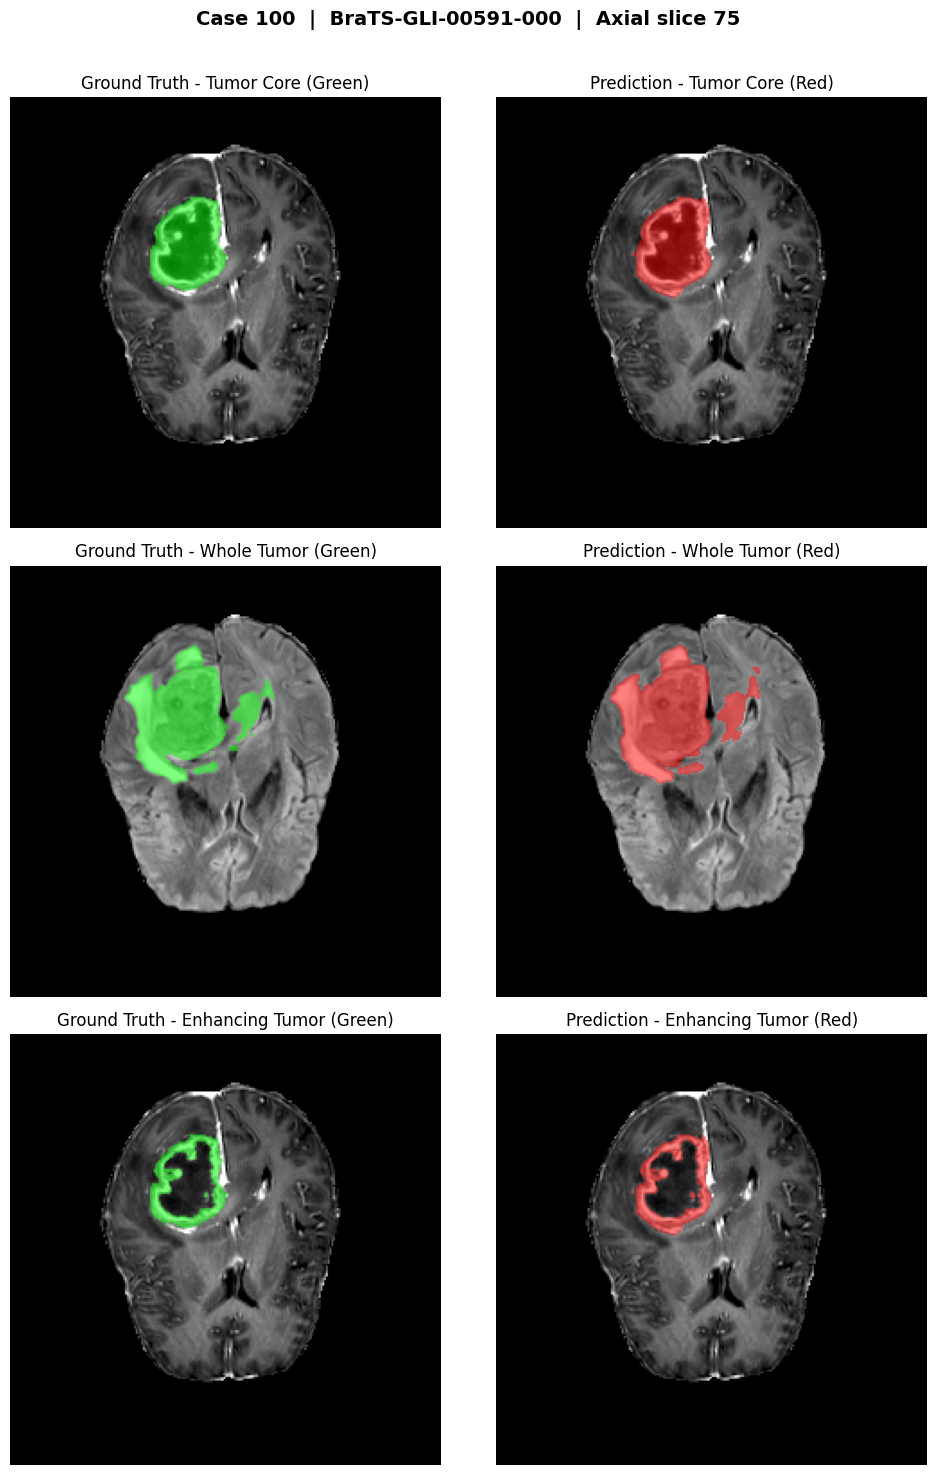

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import nibabel.processing

def visualize_case_simple(case_number, slice_number,
                   pred_dir=PRED_SAVE_DIR_DUAL,
                   data_dir=data_dir,
                   json_list=json_list,
                   fold=fold):
    """
    Visualize a specific case and slice with a simple side-by-side
    Ground Truth vs. Prediction comparison.
    """

    # ------------------------------------------------------------------ #
    # 1. Resolve file paths from JSON                                    #
    # ------------------------------------------------------------------ #
    with open(json_list) as f:
        json_data = json.load(f)["training"]

    val_files = [d for d in json_data if "fold" in d and d["fold"] == fold]

    if case_number < 1 or case_number > len(val_files):
        print(f"case_number must be between 1 and {len(val_files)}.")
        return

    entry     = val_files[case_number - 1]
    raw_paths = [os.path.join(data_dir, x) for x in entry["image"]]

    # Reorder channels exactly as get_official_val_loader does
    t1c   = next((p for p in raw_paths if 't1c' in p.lower() or 't1gd' in p.lower()), raw_paths[0])
    flair = next((p for p in raw_paths if 't2f' in p.lower()), raw_paths[3])
    label_path = os.path.join(data_dir, entry["label"])

    # Derive case stem (strip modality suffix)
    case_stem = os.path.basename(t1c).replace(".nii.gz", "").replace(".nii", "")
    for suffix in ["-t1c", "-t1n", "-t2w", "-t2f", "_t1c", "_t1n", "_t2w", "_t2f"]:
        case_stem = case_stem.replace(suffix, "")

    # ------------------------------------------------------------------ #
    # 2. Find saved prediction files                                     #
    # ------------------------------------------------------------------ #
    mask_path_full = os.path.join(pred_dir, f"{case_stem}_pred_mask.nii.gz")

    if not os.path.exists(mask_path_full):
        candidates = [f for f in os.listdir(pred_dir) if case_stem in f and "_pred_mask" in f]
        if not candidates:
            print(f"No prediction mask found for case stem '{case_stem}' in {pred_dir}.")
            return
        mask_path_full = os.path.join(pred_dir, candidates[0])



    # ------------------------------------------------------------------ #
    # 3. Load volumes and ALIGN them                                     #
    # ------------------------------------------------------------------ #
    # Load NIfTI objects
    t1c_nii   = nib.load(t1c)
    flair_nii = nib.load(flair)
    label_nii = nib.load(label_path)
    pred_nii  = nib.load(mask_path_full)

    # Get raw data for the background and ground truth
    img_t1c   = t1c_nii.get_fdata()
    img_flair = flair_nii.get_fdata()
    gt_label  = label_nii.get_fdata()

    # FIX 1: Align the prediction array to the T1c affine space
    # Because pred_mask is 4D (H, W, D, 3), we resample channel by channel
    pred_mask_raw = pred_nii.get_fdata()
    pred_mask = np.zeros_like(pred_mask_raw)

    for i in range(3):
        # Extract single channel as a 3D NIfTI
        channel_img = nib.Nifti1Image(pred_mask_raw[..., i], pred_nii.affine)
        # Resample to T1c space (order=0 means nearest neighbor, required for masks!)
        resampled_img = nibabel.processing.resample_from_to(channel_img, t1c_nii, order=0)
        pred_mask[..., i] = resampled_img.get_fdata()

    # FIX 2: Handle labels 1, 2, and 3 (instead of 4)
    if gt_label.ndim == 3:
        # Assuming 1=Necrotic/Non-enhancing, 2=Edema, 3=Enhancing Tumor
        gt_tc = ((gt_label == 1) | (gt_label == 3)).astype(np.uint8)
        gt_wt = ((gt_label == 1) | (gt_label == 2) | (gt_label == 3)).astype(np.uint8)
        gt_et = (gt_label == 3).astype(np.uint8)
    else:
        gt_tc, gt_wt, gt_et = gt_label[..., 0], gt_label[..., 1], gt_label[..., 2]

    pred_tc = pred_mask[..., 0]
    pred_wt = pred_mask[..., 1]
    pred_et = pred_mask[..., 2]

    n_slices = img_t1c.shape[2]
    if slice_number < 0 or slice_number >= n_slices:
        print(f"slice_number must be between 0 and {n_slices - 1}.")
        return

    sl = slice_number
    # ------------------------------------------------------------------ #
    # 4. Helpers for simpler visualization                               #
    # ------------------------------------------------------------------ #
    def norm(vol):
        sl_img = vol[:, :, sl]
        if sl_img.max() > 0:
            vmin, vmax = np.percentile(sl_img[sl_img > 0], [1, 99])
        else:
            vmin, vmax = 0, 1
        return np.clip((sl_img - vmin) / (vmax - vmin + 1e-8), 0, 1)

    def apply_simple_mask(bg, mask_sl, color):
        """Applies a solid color mask over a grayscale background."""
        rgb = np.stack([bg, bg, bg], axis=-1)
        m = mask_sl.astype(bool)
        alpha = 0.5 # 50% transparency
        for i in range(3):
            rgb[m, i] = rgb[m, i] * (1 - alpha) + color[i] * alpha
        return rgb

    t1c_sl   = norm(img_t1c)
    flair_sl = norm(img_flair)

    # Define colors: Green for Ground Truth, Red for Prediction
    gt_color   = [0, 1, 0]
    pred_color = [1, 0, 0]

    # ------------------------------------------------------------------ #
    # 5. Plot Side-by-Side                                               #
    # ------------------------------------------------------------------ #
    fig, axes = plt.subplots(3, 2, figsize=(10, 15))
    fig.suptitle(f"Case {case_number}  |  {case_stem}  |  Axial slice {sl}", fontsize=14, fontweight="bold")

    # Row 1: Tumor Core (TC)
    axes[0, 0].imshow(apply_simple_mask(t1c_sl.T, gt_tc[:, :, sl].T, gt_color), origin="lower")
    axes[0, 0].set_title("Ground Truth - Tumor Core (Green)")
    axes[0, 1].imshow(apply_simple_mask(t1c_sl.T, pred_tc[:, :, sl].T, pred_color), origin="lower")
    axes[0, 1].set_title("Prediction - Tumor Core (Red)")

    # Row 2: Whole Tumor (WT)
    axes[1, 0].imshow(apply_simple_mask(flair_sl.T, gt_wt[:, :, sl].T, gt_color), origin="lower")
    axes[1, 0].set_title("Ground Truth - Whole Tumor (Green)")
    axes[1, 1].imshow(apply_simple_mask(flair_sl.T, pred_wt[:, :, sl].T, pred_color), origin="lower")
    axes[1, 1].set_title("Prediction - Whole Tumor (Red)")

    # Row 3: Enhancing Tumor (ET)
    axes[2, 0].imshow(apply_simple_mask(t1c_sl.T, gt_et[:, :, sl].T, gt_color), origin="lower")
    axes[2, 0].set_title("Ground Truth - Enhancing Tumor (Green)")
    axes[2, 1].imshow(apply_simple_mask(t1c_sl.T, pred_et[:, :, sl].T, pred_color), origin="lower")
    axes[2, 1].set_title("Prediction - Enhancing Tumor (Red)")

    for ax in axes.flat:
        ax.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# --- Example usage ---
visualize_case_simple(case_number=100, slice_number=75, pred_dir=PRED_SAVE_DIR_SWIN)

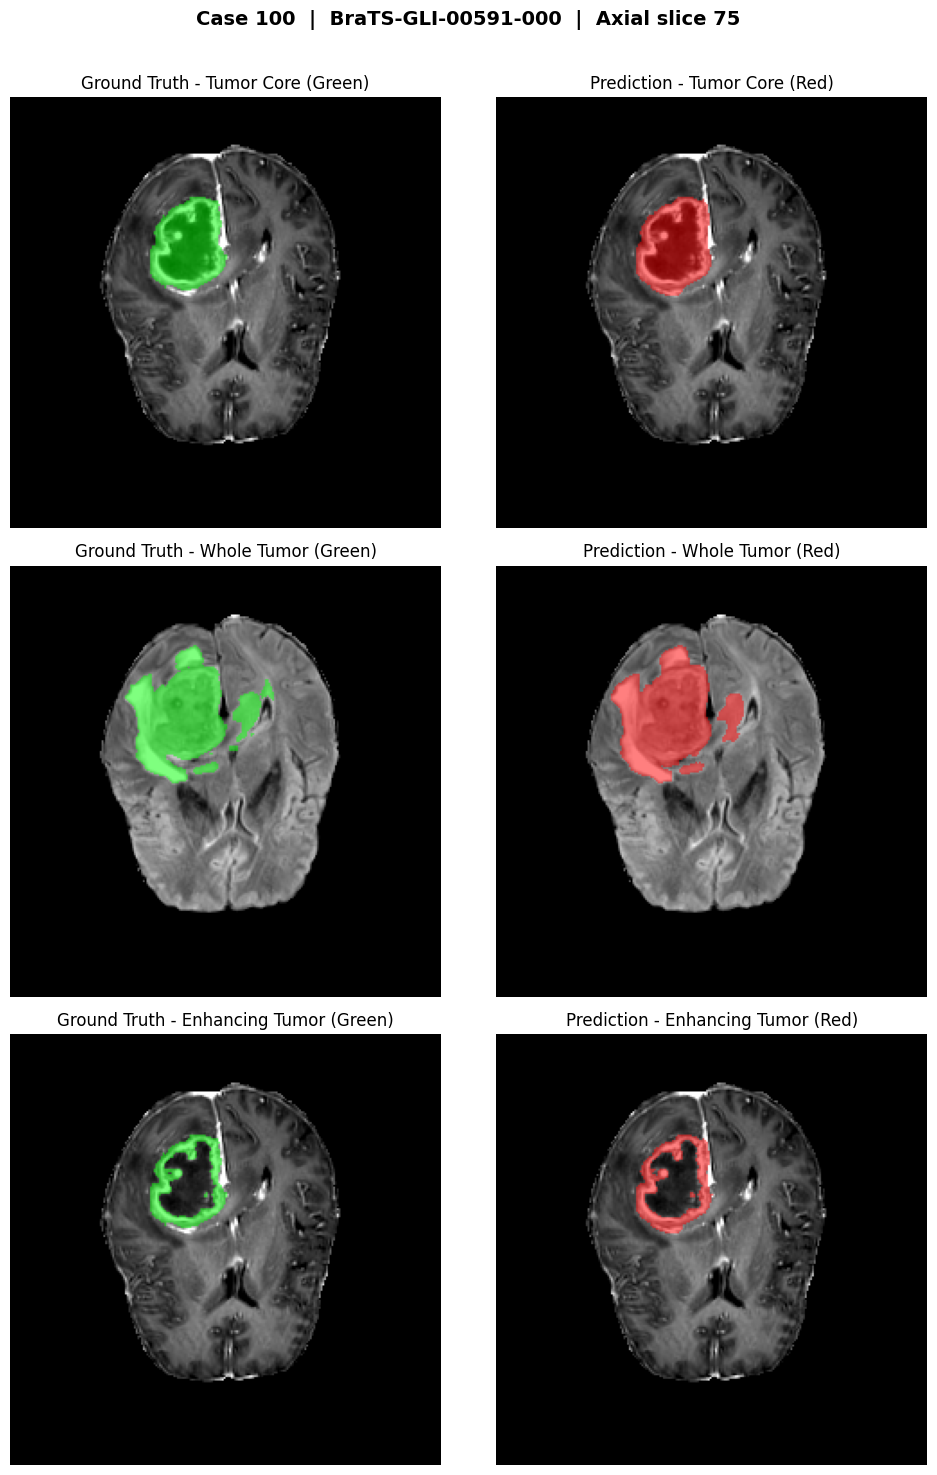

In [ ]:
visualize_case_simple(case_number=100, slice_number=75, pred_dir=PRED_SAVE_DIR_DUAL)